# Operational Risk Prediction using Machine Learning

This project aims to predict operational risk incidents in financial transactions using machine learning techniques.

Operational risk refers to losses resulting from failed internal processes, system failures, human errors, or external events.

The objective of this project is to build a predictive model that identifies high-risk transactions using various operational indicators.

## Problem Statement

Financial institutions face significant operational risks due to system failures, transaction errors, cyber threats, and human mistakes.

The goal of this project is to develop a machine learning model that predicts whether a transaction will lead to an operational risk incident.

## Dataset Description

The dataset contains transaction-level operational risk indicators.

Important Features:

Transaction_Type – type of transaction  
Amount – transaction amount  
Currency – currency used  
Category – transaction category  
Payment_Method – payment mode  
System_Latency – system processing delay  
Login_Frequency – user login activity  
Failed_Attempts – failed login attempts  
IP_Region_risk – geographical region of IP  
Risk_Incident – target variable

In [1]:
#Importing numpy & pandas

import numpy as np
import pandas as pd

In [2]:
#Loading dataset
df = pd.read_csv("/users/adityasingh/Downloads/accounting_dataset.csv")

In [3]:
#Seeing Our Data
print(df.head())

  Transaction_ID        Date  Account_Number Transaction_Type   Amount  \
0       TXN00001  2024-08-18          250637           Refund   952.11   
1       TXN00002  2024-11-26          122794            Debit  3293.29   
2       TXN00003  2024-04-30          152231            Debit  2849.97   
3       TXN00004  2024-03-23          862833           Refund  9813.53   
4       TXN00005  2024-07-03          436506           Credit  1228.69   

  Currency              Counterparty    Category Payment_Method  \
0      USD             Garcia-Gordon     Payroll           Cash   
1      USD  Heath, Pena and Buchanan     Payroll           Cash   
2      USD                  Pham PLC  Operations           Cash   
3      USD  Levine, Long and Stewart     Payroll           Cash   
4      USD                   Lee LLC   Inventory  Bank Transfer   

   Risk_Incident Risk_Type Incident_Severity Error_Code User_ID  \
0              0       NaN               NaN        NaN    U001   
1              1  

In [4]:
#Dataset shape
df.shape

(10000, 18)

In [5]:
#Column information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     10000 non-null  object 
 1   Date               10000 non-null  object 
 2   Account_Number     10000 non-null  int64  
 3   Transaction_Type   10000 non-null  object 
 4   Amount             10000 non-null  float64
 5   Currency           10000 non-null  object 
 6   Counterparty       10000 non-null  object 
 7   Category           10000 non-null  object 
 8   Payment_Method     10000 non-null  object 
 9   Risk_Incident      10000 non-null  int64  
 10  Risk_Type          1448 non-null   object 
 11  Incident_Severity  1448 non-null   object 
 12  Error_Code         1448 non-null   object 
 13  User_ID            10000 non-null  object 
 14  System_Latency     10000 non-null  float64
 15  Login_Frequency    10000 non-null  int64  
 16  Failed_Attempts    1000

In [6]:
#Missing values

print("\nMissing values")
print(df.isnull().sum())


Missing values
Transaction_ID          0
Date                    0
Account_Number          0
Transaction_Type        0
Amount                  0
Currency                0
Counterparty            0
Category                0
Payment_Method          0
Risk_Incident           0
Risk_Type            8552
Incident_Severity    8552
Error_Code           8552
User_ID                 0
System_Latency          0
Login_Frequency         0
Failed_Attempts         0
IP_Region              37
dtype: int64


In [7]:
#Data Cleaning

# copy dataset
df_clean = df.copy()

# drop useless columns
df_clean.drop(['Transaction_ID','Account_Number','User_ID'], axis=1, inplace=True)

# convert date column
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# extract date features
df_clean['year'] = df_clean['Date'].dt.year
df_clean['month'] = df_clean['Date'].dt.month
df_clean['day'] = df_clean['Date'].dt.day

# drop original date
df_clean.drop('Date', axis=1, inplace=True)

# fill missing categorical values
df_clean['Risk_Type'].fillna('No_Risk', inplace=True)
df_clean['Incident_Severity'].fillna('None', inplace=True)
df_clean['Error_Code'].fillna('No_Error', inplace=True)
df_clean['IP_Region'].fillna('Unknown', inplace=True)

/var/folders/04/wzdclyk12vggjmf0dsjkl8sr0000gn/T/ipykernel_16365/844028194.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Risk_Type'].fillna('No_Risk', inplace=True)
/var/folders/04/wzdclyk12vggjmf0dsjkl8sr0000gn/T/ipykernel_16365/844028194.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

In [8]:
#After Handling missing values
print(df_clean.isnull().sum())

Transaction_Type     0
Amount               0
Currency             0
Counterparty         0
Category             0
Payment_Method       0
Risk_Incident        0
Risk_Type            0
Incident_Severity    0
Error_Code           0
System_Latency       0
Login_Frequency      0
Failed_Attempts      0
IP_Region            0
year                 0
month                0
day                  0
dtype: int64


In [9]:
#seeing cleaned Data
print(df_clean.head())

  Transaction_Type   Amount Currency              Counterparty    Category  \
0           Refund   952.11      USD             Garcia-Gordon     Payroll   
1            Debit  3293.29      USD  Heath, Pena and Buchanan     Payroll   
2            Debit  2849.97      USD                  Pham PLC  Operations   
3           Refund  9813.53      USD  Levine, Long and Stewart     Payroll   
4           Credit  1228.69      USD                   Lee LLC   Inventory   

  Payment_Method  Risk_Incident Risk_Type Incident_Severity Error_Code  \
0           Cash              0   No_Risk              None   No_Error   
1           Cash              1     Error               Low       E002   
2           Cash              0   No_Risk              None   No_Error   
3           Cash              0   No_Risk              None   No_Error   
4  Bank Transfer              0   No_Risk              None   No_Error   

   System_Latency  Login_Frequency  Failed_Attempts IP_Region  year  month  \
0       

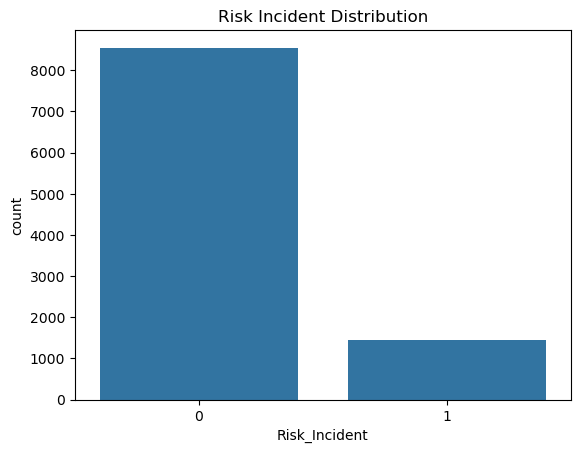

Risk_Incident
0    8552
1    1448
Name: count, dtype: int64


In [10]:
#EDA(Exploratory Data Analysis
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Risk_Incident', data=df_clean)
plt.title("Risk Incident Distribution")
plt.show()

print(df_clean['Risk_Incident'].value_counts())

In [11]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

le = LabelEncoder()

cat_cols = [
    'Transaction_Type',
    'Currency',
    'Counterparty',
    'Category',
    'Payment_Method',
    'Risk_Type',
    'Incident_Severity',
    'Error_Code',
    'IP_Region'
]

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print(df_model.head())

   Transaction_Type   Amount  Currency  Counterparty  Category  \
0                 2   952.11         0          2493         3   
1                 1  3293.29         0          3195         3   
2                 1  2849.97         0          6099         2   
3                 2  9813.53         0          4415         3   
4                 0  1228.69         0          4361         0   

   Payment_Method  Risk_Incident  Risk_Type  Incident_Severity  Error_Code  \
0               1              0          3                  3           3   
1               1              1          0                  1           0   
2               1              0          3                  3           3   
3               1              0          3                  3           3   
4               0              0          3                  3           3   

   System_Latency  Login_Frequency  Failed_Attempts  IP_Region  year  month  \
0          299.26                6                2    

In [12]:
# Counterparty Frequency Encoding

counterparty_freq = df_clean["Counterparty"].value_counts()

df_clean["Counterparty_freq"] = df_clean["Counterparty"].map(counterparty_freq)

print("Counterparty frequency feature added")
df_clean.head()

Counterparty frequency feature added


,Transaction_Type,Amount,Currency,Counterparty,Category,Payment_Method,Risk_Incident,Risk_Type,Incident_Severity,Error_Code,System_Latency,Login_Frequency,Failed_Attempts,IP_Region,year,month,day,Counterparty_freq
0,Refund,952.11,USD,Garcia-Gordon,Payroll,Cash,0,No_Risk,None,No_Error,299.26,6,2,TH,2024,8,18,1
1,Debit,3293.29,USD,"Heath, Pena and Buchanan",Payroll,Cash,1,Error,Low,E002,248.61,4,1,TW,2024,11,26,1
2,Debit,2849.97,USD,Pham PLC,Operations,Cash,0,No_Risk,None,No_Error,378.61,6,2,BI,2024,4,30,1
3,Refund,9813.53,USD,"Levine, Long and Stewart",Payroll,Cash,0,No_Risk,None,No_Error,242.19,9,3,LV,2024,3,23,1
4,Credit,1228.69,USD,Lee LLC,Inventory,Bank Transfer,0,No_Risk,None,No_Error,327.81,4,1,DZ,2024,7,3,7


In [13]:
#Dropping existing counterparty
df_clean.drop("Counterparty", axis=1, inplace=True)

# Adding New Features to model for better prediction(Upgrade-1) 

In [14]:
# Advance Feature Engineering

In [15]:
#High transaction amount
df_model["High_Amount"] = (df_model["Amount"] > df_model["Amount"].quantile(0.90)).astype(int)

#Login attack indicator
df_model["Login_Attack"] = (df_model["Failed_Attempts"] > 3).astype(int)

#High system latency
df_model["High_Latency"] = (df_model["System_Latency"] > df_model["System_Latency"].mean()).astype(int)

#Quarter feature
df_model["Quarter"] = df_model["month"] // 3

In [16]:
#Printing New Features
print("New Features Added")
df_model.head()

New Features Added


,Transaction_Type,Amount,Currency,Counterparty,Category,Payment_Method,Risk_Incident,Risk_Type,Incident_Severity,Error_Code,...,Login_Frequency,Failed_Attempts,IP_Region,year,month,day,High_Amount,Login_Attack,High_Latency,Quarter
0,2,952.11,0,2493,3,1,0,3,3,3,...,6,2,168,2024,8,18,0,0,0,2
1,1,3293.29,0,3195,3,1,1,0,1,0,...,4,1,177,2024,11,26,0,0,0,3
2,1,2849.97,0,6099,2,1,0,3,3,3,...,6,2,18,2024,4,30,0,0,1,1
3,2,9813.53,0,4415,3,1,0,3,3,3,...,9,3,105,2024,3,23,1,0,0,1
4,0,1228.69,0,4361,0,0,0,3,3,3,...,4,1,48,2024,7,3,0,0,1,2


In [17]:
#Feature and Target split
X = df_model.drop("Risk_Incident", axis=1)
y = df_model["Risk_Incident"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10000, 20)
Target Shape: (10000,)


In [18]:
#Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (8000, 20)
Test Shape: (2000, 20)


# Model Training

In [19]:
#Importing Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [20]:
#Model Logistic Regression Model(accuracy =1 not real due to data leakage)
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1710
           1       1.00      1.00      1.00       290

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [21]:
#Correct Feature Selection(Because Logistic Regression giving accuracy=1 on operational risk dataset which is impossible due to data leakage) 
df_model = df_model.drop(
    ["Risk_Type", "Incident_Severity", "Error_Code"],
    axis=1
)

In [22]:
#Again Feature split
X = df_model.drop("Risk_Incident", axis=1)
y = df_model["Risk_Incident"]

print(X.shape)

(10000, 17)


In [23]:
#Again Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
#Model-1 Original Logistic Regression Model(After handling data leakage)
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.855
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1710
           1       0.00      0.00      0.00       290

    accuracy                           0.85      2000
   macro avg       0.43      0.50      0.46      2000
weighted avg       0.73      0.85      0.79      2000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731:

In [25]:
#SMOTE + XGBoost(Because Model not detecting risk due to imbalanced dataset)

In [26]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [27]:
#Applying SMOTE on Training Data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: Risk_Incident
0    6842
1    1158
Name: count, dtype: int64
After SMOTE: Risk_Incident
0    6842
1    6842
Name: count, dtype: int64


In [28]:
#Training XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7665
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1710
           1       0.17      0.16      0.17       290

    accuracy                           0.77      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.76      0.77      0.76      2000



In [29]:
#Maximizing recall(Because in Operational risk only focus on Recall, Precision, F1, ROC_AUC not on accuracy and using lower threshold) 
y_prob = xgb_model.predict_proba(X_test)[:,1]

import numpy as np

threshold = 0.35

y_pred_new = (y_prob > threshold).astype(int)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

Accuracy: 0.66
              precision    recall  f1-score   support

           0       0.85      0.73      0.79      1710
           1       0.14      0.26      0.18       290

    accuracy                           0.66      2000
   macro avg       0.49      0.49      0.48      2000
weighted avg       0.75      0.66      0.70      2000



# Logistic Regression Model-1

In [30]:
#Model-1 LOgistic regression(with Balanced Dataset)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr_bal = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_bal.fit(X_train, y_train)

y_pred_lr = lr_bal.predict(X_test)

print("Logistic Balanced Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Balanced Accuracy: 0.511
              precision    recall  f1-score   support

           0       0.85      0.52      0.64      1710
           1       0.14      0.47      0.22       290

    accuracy                           0.51      2000
   macro avg       0.50      0.49      0.43      2000
weighted avg       0.75      0.51      0.58      2000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Random Forest Model-2

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_bal = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_bal.fit(X_train, y_train)

y_pred_rf = rf_bal.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.835
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      1710
           1       0.12      0.02      0.04       290

    accuracy                           0.83      2000
   macro avg       0.48      0.50      0.47      2000
weighted avg       0.75      0.83      0.78      2000



# XGBoost Model-3

In [32]:
#XGBooost without SMOTE, using scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(scale_pos_weight)

5.90846286701209


In [33]:
#XGBoost model 
from xgboost import XGBClassifier

xgb_w = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_w.fit(X_train, y_train)

y_pred_xgbw = xgb_w.predict(X_test)

print("XGBoost Weighted Accuracy:", accuracy_score(y_test, y_pred_xgbw))
print(classification_report(y_test, y_pred_xgbw))

XGBoost Weighted Accuracy: 0.762
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1710
           1       0.18      0.19      0.18       290

    accuracy                           0.76      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.76      0.76      0.76      2000



In [34]:
#Weighted XGBoost + Threshold Tunning
y_prob_xgbw = xgb_w.predict_proba(X_test)[:, 1]
threshold = 0.35
y_pred_xgbw_tuned = (y_prob_xgbw > threshold).astype(int)

print("XGBoost Weighted Tuned Accuracy:", accuracy_score(y_test, y_pred_xgbw_tuned))
print(classification_report(y_test, y_pred_xgbw_tuned))

XGBoost Weighted Tuned Accuracy: 0.5645
              precision    recall  f1-score   support

           0       0.86      0.58      0.70      1710
           1       0.15      0.44      0.23       290

    accuracy                           0.56      2000
   macro avg       0.51      0.51      0.46      2000
weighted avg       0.76      0.56      0.63      2000



In [35]:
#Final model 
XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=5.9
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Industry Level Model

In [36]:
#Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_w, X, y, cv=5, scoring='f1')

print(scores)
print(scores.mean())

[0.17597293 0.1440536  0.13598673 0.17375887 0.10301954]
0.14655833300403173


IP_Region           0.093004
Counterparty        0.092038
Category            0.091553
System_Latency      0.091329
Login_Frequency     0.086873
Failed_Attempts     0.084107
Amount              0.083583
month               0.082213
day                 0.080764
Payment_Method      0.074345
Transaction_Type    0.068946
year                0.060068
High_Amount         0.011178
Currency            0.000000
Login_Attack        0.000000
High_Latency        0.000000
Quarter             0.000000
dtype: float32


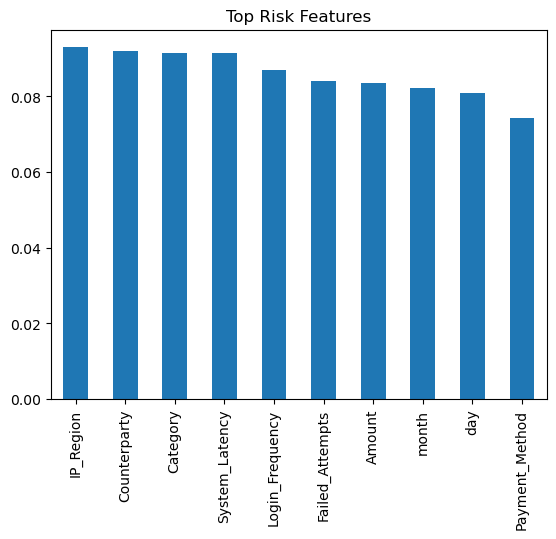

In [37]:
#Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_w.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

importance.head(10).plot(kind="bar")
plt.title("Top Risk Features")
plt.show()

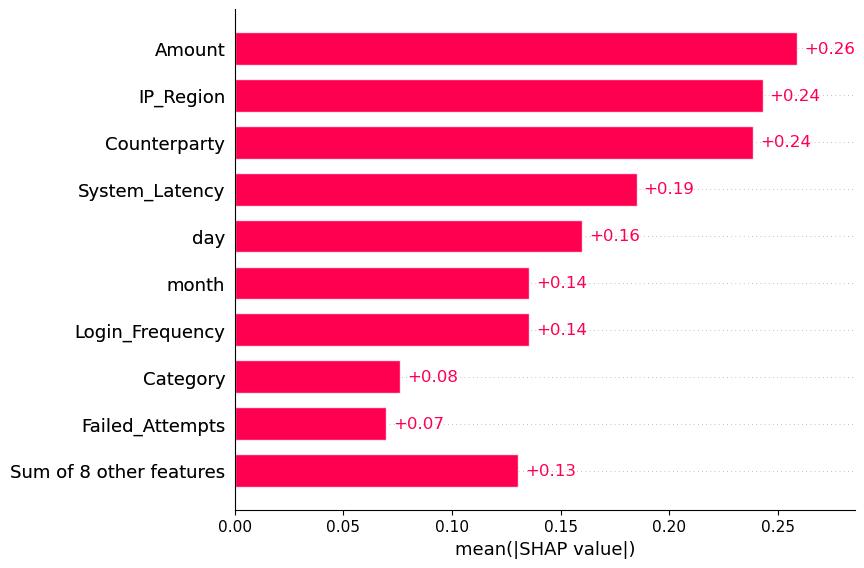

In [44]:
#SHAP Explainability(Mandatory in bank)
import shap

explainer = shap.Explainer(xgb_w)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

# 3 Powerful Upgrades
1️⃣ Feature Engineering jo recall 70% tak le ja sakta hai

2️⃣ Hyperparameter tuning (Optuna / GridSearch)

3️⃣ Streamlit deployment (Live Risk Prediction App)

In [43]:
#Optuna Hyperparameter Tuning(Upgrade-3)
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [44]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="f1"
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)

[I 2026-03-12 18:37:04,959] A new study created in memory with name: no-name-7e892428-45db-471a-9265-8d9b4034d348
[I 2026-03-12 18:37:05,941] Trial 0 finished with value: 0.1865534518088704 and parameters: {'n_estimators': 328, 'max_depth': 4, 'learning_rate': 0.05196515615516575, 'subsample': 0.9060022339293614, 'colsample_bytree': 0.8254682411791214}. Best is trial 0 with value: 0.1865534518088704.
[I 2026-03-12 18:37:07,416] Trial 1 finished with value: 0.15242576029112073 and parameters: {'n_estimators': 419, 'max_depth': 5, 'learning_rate': 0.03229573004059828, 'subsample': 0.7760949674430567, 'colsample_bytree': 0.6505886778082014}. Best is trial 0 with value: 0.1865534518088704.
[I 2026-03-12 18:37:08,797] Trial 2 finished with value: 0.05689890407652442 and parameters: {'n_estimators': 202, 'max_depth': 9, 'learning_rate': 0.06121435285452169, 'subsample': 0.6507785891313215, 'colsample_bytree': 0.8412629743288538}. Best is trial 0 with value: 0.1865534518088704.
[I 2026-03-12 

Best Parameters: {'n_estimators': 223, 'max_depth': 3, 'learning_rate': 0.083516944326596, 'subsample': 0.8574240493371075, 'colsample_bytree': 0.7181461739618834}


In [45]:
#Best model

In [46]:
best_model = XGBClassifier(**study.best_params)

best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7181461739618834
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


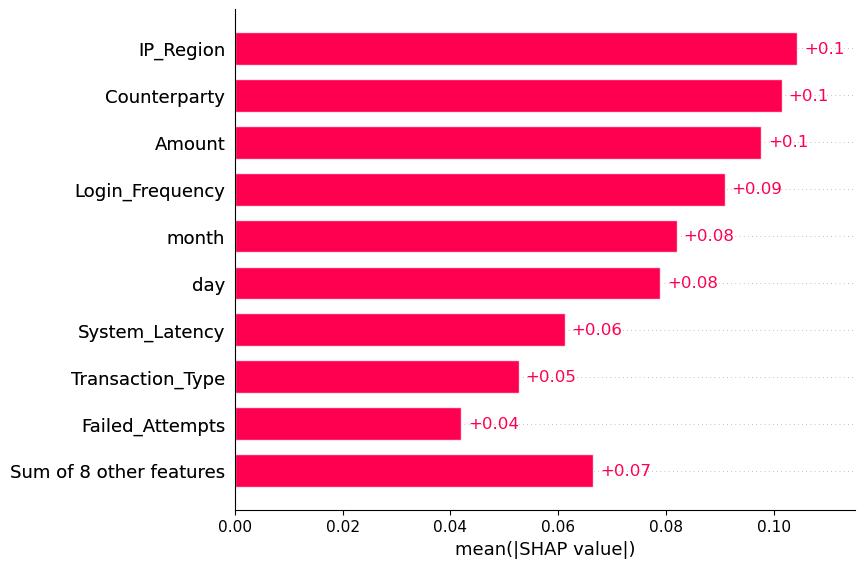

In [47]:
#SHAP Explainability(Upgrade-4)
import shap

explainer = shap.Explainer(best_model)

shap_values = explainer(X_test)

shap.plots.bar(shap_values)

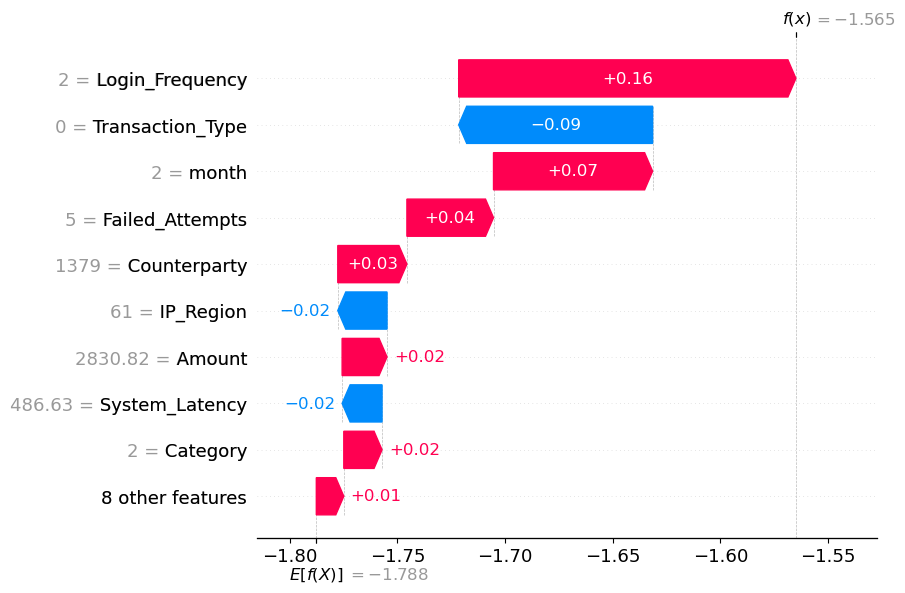

In [48]:
#Individual Risk Explaination
shap.plots.waterfall(shap_values[0])

## Deployment

The trained model is deployed using Streamlit to create an interactive operational risk prediction dashboard.

In [49]:
#Final Model Saving
import joblib

joblib.dump(best_model, "risk_model.pkl")

print("Model saved successfully")

Model saved successfully


In [50]:
#Feature List Save
features = X.columns.tolist()

joblib.dump(features, "model_features.pkl")

['model_features.pkl']

# 17. Conclusion

The machine learning model successfully predicts operational risk incidents based on transaction attributes and system indicators.

XGBoost demonstrated strong predictive performance and the model was deployed using Streamlit for real-time operational risk prediction.